In [ ]:
import pandas as pd
import numpy as np
import seaborn as sb
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/block_0.csv/block_0.csv')

In [ ]:
df_w = pd.read_csv('/content/drive/MyDrive/weather_hourly_darksky.csv')

In [ ]:
df.head()

,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0


In [ ]:
df.dtypes

LCLid             object
tstp              object
energy(kWh/hh)    object
dtype: object

In [ ]:
df = df.rename(columns ={'energy(kWh/hh)':'energy'})

In [ ]:
df =df.dropna()

In [ ]:
i = df[df['energy'] == 'Null'].index
df = df.drop(index=i)

In [ ]:
df['energy']=df['energy'].astype('float')

In [ ]:
df['tstp'] = df['tstp'].astype('datetime64')

In [ ]:
df.dtypes

LCLid             object
tstp      datetime64[ns]
energy           float64
dtype: object

In [ ]:
df_w.head()

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy


In [ ]:
df_w['time'] =df_w['time'].astype('datetime64')

In [ ]:
df_w.dtypes

visibility                    float64
windBearing                     int64
temperature                   float64
time                   datetime64[ns]
dewPoint                      float64
pressure                      float64
apparentTemperature           float64
windSpeed                     float64
precipType                     object
icon                           object
humidity                      float64
summary                        object
dtype: object

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
df_w = df_w.drop(columns=['windBearing','precipType','icon','summary'])
df_w.columns

Index(['visibility', 'temperature', 'time', 'dewPoint', 'pressure',
       'apparentTemperature', 'windSpeed', 'humidity'],
      dtype='object')

In [ ]:
df_w =df_w.rename(columns ={'visibility':'Visibility','temperature':'Temperature','pressure':'Pressure',
                            'dewPoint':'Dew point','apparentTemperature':'Apparent temp','windSpeed':'Wind speed' ,'humidity':'Humidity'})

In [ ]:
df_w.columns

Index(['Visibility', 'Temperature', 'time', 'Dew point', 'Pressure',
       'Apparent temp', 'Wind speed', 'Humidity'],
      dtype='object')

In [ ]:
df_w_corr = df_w.corr()

<ipython-input-176-6202664f5592>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_w_corr = df_w.corr()


In [ ]:
df_w_corr

,Visibility,Temperature,Dew point,Pressure,Apparent temp,Wind speed,Humidity
Visibility,1.000000,0.239187,-0.022403,-0.011675,0.194617,0.237331,-0.528679
Temperature,0.239187,1.000000,0.843129,0.049692,0.986582,0.053077,-0.422984
Dew point,-0.022403,0.843129,1.000000,-0.050645,0.855472,-0.033720,0.123215
Pressure,-0.011675,0.049692,-0.050645,1.000000,0.081949,-0.365183,-0.173080
Apparent temp,0.194617,0.986582,0.855472,0.081949,1.000000,-0.025028,-0.375860
Wind speed,0.237331,0.053077,-0.033720,-0.365183,-0.025028,1.000000,-0.189340
Humidity,-0.528679,-0.422984,0.123215,-0.173080,-0.375860,-0.189340,1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

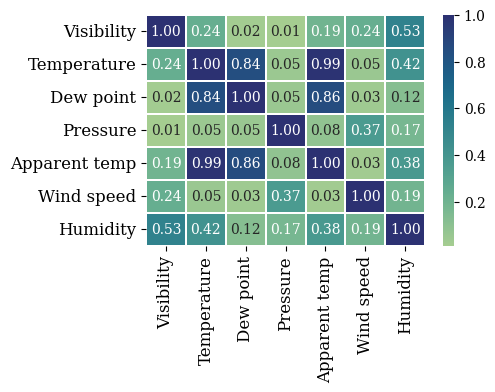

In [ ]:
# correlations for energy readings and weather variables for households individual readings
plt.figure(figsize=[4.5,3])
sb.heatmap(df_w_corr.abs(),annot= True,fmt ='.2f',cmap='crest',linewidth=.05);

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("weather quantitaive variables correlation.png",dpi = 300 , bbox_inches = 'tight')
files.download("weather quantitaive variables correlation.png")

In [ ]:
df = df.merge(df_w, how='inner' ,left_on='tstp', right_on='time' )

In [ ]:
df.head(2)

,LCLid,tstp,energy,Visibility,Temperature,time,Dew point,Pressure,Apparent temp,Wind speed,Humidity
0,MAC000002,2012-10-12 01:00:00,0.000,13.5,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,0.89
1,MAC000246,2012-10-12 01:00:00,0.532,13.5,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,0.89


In [ ]:
df.shape

(611234, 11)

In [ ]:
df_corr =df

In [ ]:
df_corr =df_corr.rename(columns = {'energy':'Inst. energy'})

In [ ]:
df_heat = df_corr.corr()

<ipython-input-184-a2249ed45c2a>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_heat = df_corr.corr()


In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

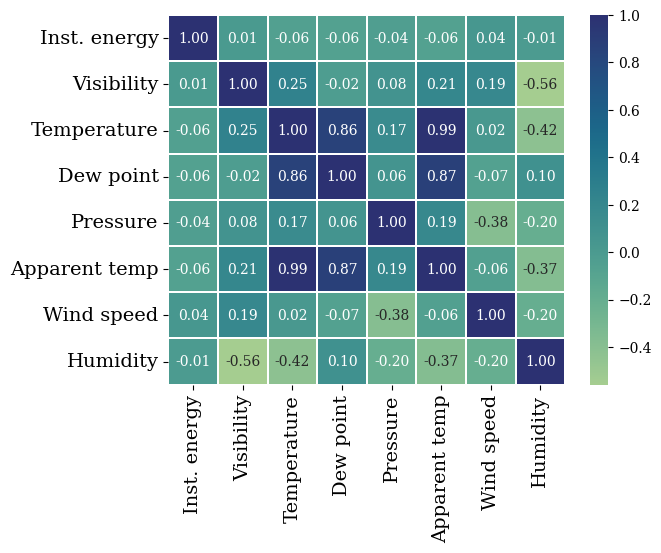

In [ ]:
# correlations for energy readings and weather variables for households individual readings
sb.heatmap(df_heat,annot= True,fmt ='.2f',cmap='crest',linewidth=.05);

plt.xticks(fontsize = 14  )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("eergy correlatio for idividual eergy cosumtio measuremet with weather variables.png",dpi = 300 , bbox_inches = 'tight')
files.download("eergy correlatio for idividual eergy cosumtio measuremet with weather variables.png")

In [ ]:
df_heat.abs()

,Inst. energy,Visibility,Temperature,Dew point,Pressure,Apparent temp,Wind speed,Humidity
Inst. energy,1.000000,0.009486,0.056305,0.062603,0.035500,0.060253,0.035813,0.006299
Visibility,0.009486,1.000000,0.248790,0.020214,0.075920,0.206300,0.188422,0.558965
Temperature,0.056305,0.248790,1.000000,0.855379,0.165705,0.986942,0.023178,0.422551
Dew point,0.062603,0.020214,0.855379,1.000000,0.063586,0.869741,0.067733,0.100666
Pressure,0.035500,0.075920,0.165705,0.063586,1.000000,0.193974,0.384397,0.203155
Apparent temp,0.060253,0.206300,0.986942,0.869741,0.193974,1.000000,0.055169,0.370475
Wind speed,0.035813,0.188422,0.023178,0.067733,0.384397,0.055169,1.000000,0.200980
Humidity,0.006299,0.558965,0.422551,0.100666,0.203155,0.370475,0.200980,1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

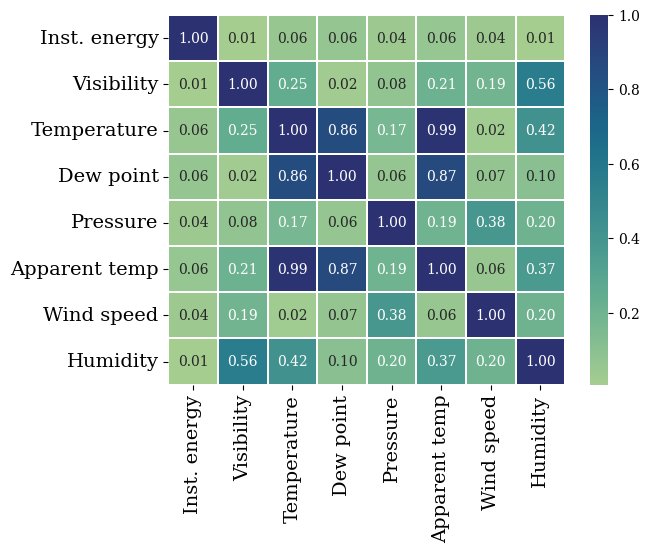

In [ ]:
# correlations for energy readings and weather variables for households individual readings
sb.heatmap(df_heat.abs(),annot= True,fmt ='.2f',cmap='crest',linewidth=.05);

plt.xticks(fontsize = 14  )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("eergy absolute correlatio for idividual eergy cosumtio measuremet with weather variables.png",dpi=300,bbox_inches ='tight')
files.download("eergy absolute correlatio for idividual eergy cosumtio measuremet with weather variables.png")

## energy correlations for the whole block

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/block_0.csv/block_0.csv')

In [ ]:
df_w = pd.read_csv('/content/drive/MyDrive/weather_hourly_darksky.csv')

In [ ]:
df.dtypes

LCLid             object
tstp              object
energy(kWh/hh)    object
dtype: object

In [ ]:
df = df.rename(columns = {'energy(kWh/hh)':'energy'})

In [ ]:
i = df[df['energy'] == 'Null'].index
df = df.drop(index=i)

In [ ]:
df['energy'] = df['energy'].astype('float')

In [ ]:
df['tstp'] = df['tstp'].astype('datetime64')


In [ ]:
df.dtypes

LCLid             object
tstp      datetime64[ns]
energy           float64
dtype: object

In [ ]:
df_w['time'] =df_w['time'].astype('datetime64')

In [ ]:
df_sum = df.groupby(['tstp']).sum('energy')

In [ ]:
df = df_sum.merge(df_w ,how = 'inner' , left_on='tstp' ,right_on = 'time')

In [ ]:
df.head()

,energy,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,0.149,13.07,262,11.00,2011-12-03 09:00:00,8.84,1002.07,11.00,5.99,rain,partly-cloudy-day,0.87,Partly Cloudy
1,0.768,12.76,268,11.42,2011-12-03 10:00:00,7.52,1002.76,11.42,6.10,rain,partly-cloudy-day,0.77,Partly Cloudy
2,0.588,13.07,274,11.41,2011-12-03 11:00:00,6.39,1003.24,11.41,6.20,rain,partly-cloudy-day,0.71,Partly Cloudy
3,0.843,13.07,277,11.33,2011-12-03 12:00:00,5.42,1003.22,11.33,6.60,rain,partly-cloudy-day,0.67,Partly Cloudy
4,0.120,13.07,277,11.41,2011-12-03 13:00:00,5.07,1003.29,11.41,7.05,rain,partly-cloudy-day,0.65,Partly Cloudy


In [ ]:
df['energy'].describe()

count    19622.000000
mean        14.017818
std         10.529311
min          0.023000
25%          4.814250
50%         13.173000
75%         21.209250
max         53.815000
Name: energy, dtype: float64

We noticed that the sum of energy consumptions are sometimes very low and this is because there were a lot of missing readings in energy consumption readings for some days. We filter the energy readings to only include the values with sum higher than 2

In [ ]:
df = df[df['energy'] > 4]

In [ ]:
df.head()

,energy,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
2725,4.478,8.14,69,6.26,2012-03-25 22:00:00,4.52,1035.64,4.08,2.91,rain,clear-night,0.89,Clear
2916,5.831,13.65,342,10.70,2012-04-02 21:00:00,3.32,1006.89,10.70,1.46,rain,partly-cloudy-night,0.60,Partly Cloudy
2930,4.154,12.68,261,12.59,2012-04-03 11:00:00,4.40,1003.13,12.59,2.46,rain,partly-cloudy-day,0.57,Partly Cloudy
2940,4.657,11.86,216,7.73,2012-04-03 21:00:00,6.79,1001.57,7.17,1.42,rain,partly-cloudy-night,0.94,Partly Cloudy
2942,4.300,11.97,252,7.79,2012-04-03 23:00:00,6.72,1001.53,6.51,2.13,rain,partly-cloudy-night,0.93,Partly Cloudy


In [ ]:
df = df.drop(columns = ['time','windBearing','precipType','icon','summary'])

In [ ]:
df.columns

Index(['energy', 'visibility', 'temperature', 'dewPoint', 'pressure',
       'apparentTemperature', 'windSpeed', 'humidity'],
      dtype='object')

In [ ]:
df = df.rename(columns = {'apparentTemperature':'Apparent temp','humidity':'Humidity' , 'windSpeed':'Wind speed' ,'visibility':'Visibility',
"temperature":"Temperature" , 'dewPoint':'Dew point','pressure':'Pressure' ,'energy':'Energy sum'})

In [ ]:
df.columns

Index(['Energy sum', 'Visibility', 'Temperature', 'Dew point', 'Pressure',
       'Apparent temp', 'Wind speed', 'Humidity'],
      dtype='object')

In [ ]:
df.head(1)

,Energy sum,Visibility,Temperature,Dew point,Pressure,Apparent temp,Wind speed,Humidity
2725,4.478,8.14,6.26,4.52,1035.64,4.08,2.91,0.89


In [ ]:
df_corr = df.corr()

In [ ]:
df_corr

,Energy sum,Visibility,Temperature,Dew point,Pressure,Apparent temp,Wind speed,Humidity
Energy sum,1.000000,-0.066934,-0.430023,-0.441708,-0.093834,-0.447044,0.120699,0.060574
Visibility,-0.066934,1.000000,0.263171,0.002111,0.080265,0.225773,0.177023,-0.545518
Temperature,-0.430023,0.263171,1.000000,0.851376,0.172839,0.988524,0.009058,-0.449908
Dew point,-0.441708,0.002111,0.851376,1.000000,0.067926,0.868092,-0.083248,0.077952
Pressure,-0.093834,0.080265,0.172839,0.067926,1.000000,0.196852,-0.385774,-0.210199
Apparent temp,-0.447044,0.225773,0.988524,0.868092,0.196852,1.000000,-0.058347,-0.398390
Wind speed,0.120699,0.177023,0.009058,-0.083248,-0.385774,-0.058347,1.000000,-0.193917
Humidity,0.060574,-0.545518,-0.449908,0.077952,-0.210199,-0.398390,-0.193917,1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

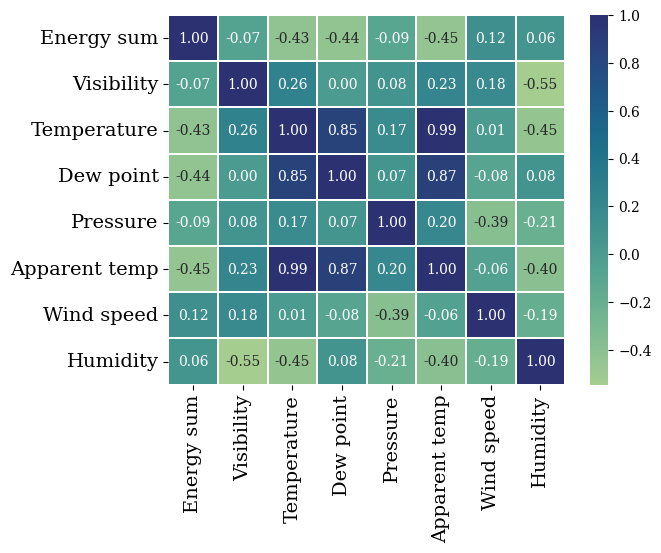

In [ ]:
# correlations for energy readings and weather variables for households individual readings
sb.heatmap(df_corr,annot= True,fmt ='.2f',cmap='crest',linewidth=.05);
plt.xticks(fontsize = 14  )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("correlatio of eergy sum of all households' eergy cosumtios with weather variables.png",dpi=300, bbox_inches='tight')
files.download("correlatio of eergy sum of all households' eergy cosumtios with weather variables.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

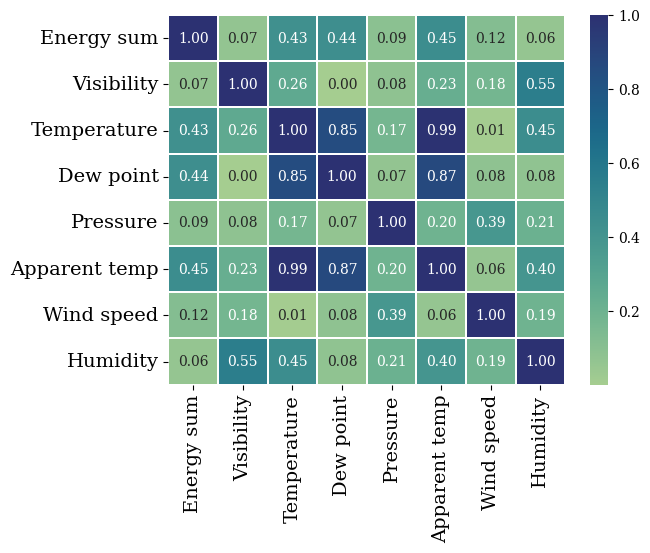

In [ ]:
# correlations for energy readings and weather variables for households individual readings

sb.heatmap(df_corr.abs(),annot= True,fmt ='.2f',cmap='crest',linewidth=.05);
plt.xticks(fontsize = 14  )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("Absolute correlatio of eergy sum of all households' eergy cosumtios with weather variables.png",dpi = 300 , bbox_inches='tight')
files.download("Absolute correlatio of eergy sum of all households' eergy cosumtios with weather variables.png")

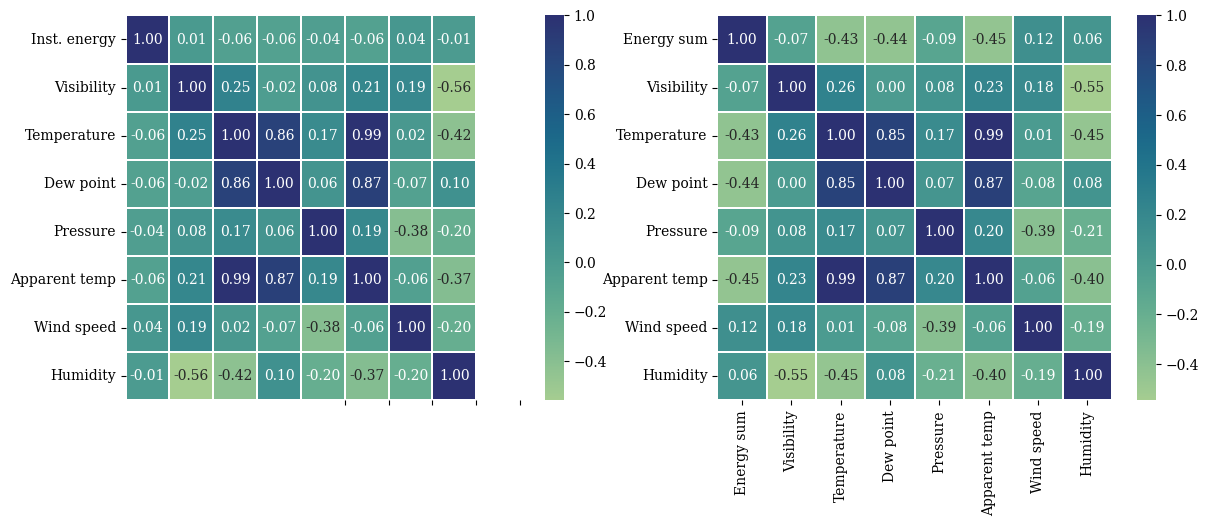

In [ ]:

plt.figure(figsize = [14,5])
plt.subplot(1,2,1)
sb.heatmap(df_heat,annot= True,fmt ='.2f',cmap='crest',linewidth=.05);
plt.xticks(np.arange(5,10,1))
plt.subplot(1,2,2)
sb.heatmap(df_corr,annot= True,fmt ='.2f',cmap='crest',linewidth=.05);


## Trying to put Energy and sum energy next to each other

In [ ]:
df_heat.columns

Index(['Inst. energy', 'Visibility', 'Temperature', 'Dew point', 'Pressure',
       'Apparent temp', 'Wind speed', 'Humidity'],
      dtype='object')

In [ ]:
df_corr.columns

Index(['Energy sum', 'Visibility', 'Temperature', 'Dew point', 'Pressure',
       'Apparent temp', 'Wind speed', 'Humidity'],
      dtype='object')

In [ ]:
df_new = pd.concat([df_heat['Inst. energy'] , df_corr['Energy sum']] ,axis=1)
#df_heat['Inst. energy'].conact(df_corr['Energy sum'] ,axis = 0)

In [ ]:
df_new = df_new.drop(index=['Inst. energy','Energy sum'])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

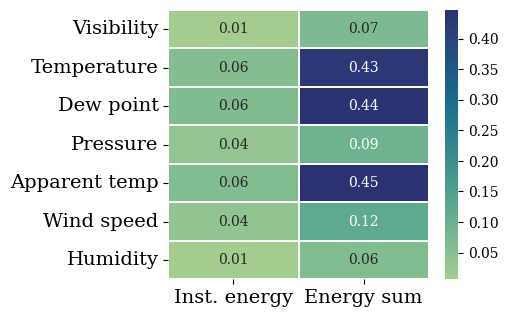

In [ ]:
# correlations for energy readings and weather variables for households individual readings
plt.figure(figsize = [4.2,3.5])
sb.heatmap(df_new.abs(), annot= True, fmt ='.2f', cmap='crest', linewidth=.05);
plt.xticks(fontsize = 14 )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("Inst. energy and Energy sum Vs weather variables.png",dpi=300, bbox_inches='tight')
files.download("Inst. energy and Energy sum Vs weather variables.png")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/block_0.csv/block_0.csv')

In [ ]:
df_w = pd.read_csv('/content/drive/MyDrive/weather_hourly_darksky.csv')

In [ ]:
df.columns

Index(['LCLid', 'tstp', 'energy(kWh/hh)'], dtype='object')

In [ ]:
df.dtypes

LCLid             object
tstp              object
energy(kWh/hh)    object
dtype: object

In [ ]:
df =df.rename(columns = {'energy(kWh/hh)':'energy'})

In [ ]:
df['tstp'] = df['tstp'].astype('datetime64')

In [ ]:
i = df[df['energy'] == 'Null'].index
df = df.drop(index= i)

In [ ]:
df_w['time'] = df_w['time'].astype('datetime64')

In [ ]:
df = df.merge(df_w , how='inner', left_on='tstp', right_on='time')
df.head()

,LCLid,tstp,energy,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,MAC000002,2012-10-12 01:00:00,0,13.5,250,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,rain,wind,0.89,Breezy and Mostly Cloudy
1,MAC000246,2012-10-12 01:00:00,0.532,13.5,250,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,rain,wind,0.89,Breezy and Mostly Cloudy
2,MAC000450,2012-10-12 01:00:00,1.072,13.5,250,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,rain,wind,0.89,Breezy and Mostly Cloudy
3,MAC001074,2012-10-12 01:00:00,0.21,13.5,250,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,rain,wind,0.89,Breezy and Mostly Cloudy
4,MAC003223,2012-10-12 01:00:00,0.151,13.5,250,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,rain,wind,0.89,Breezy and Mostly Cloudy


In [ ]:
df.head(1)

,LCLid,tstp,energy,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,MAC000002,2012-10-12 01:00:00,0,13.5,250,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,rain,wind,0.89,Breezy and Mostly Cloudy


In [ ]:
df=df.drop(columns =['LCLid','tstp' ,'windBearing','summary','precipType','icon'])

In [ ]:
energy= pd.Series(df['energy'])

In [ ]:
#df=df.drop(columns = ['energy'])

In [ ]:
df.head(1)

,energy,visibility,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,humidity
0,0,13.5,13.09,2012-10-12 01:00:00,11.37,1000.1,13.09,6.77,0.89


In [ ]:
energy =energy.astype('float')

In [ ]:
df_corr1 = df.corrwith(energy)

<ipython-input-77-d5ef8f4a7e9f>:1: FutureWarning: The default value of numeric_only in DataFrame.corrwith is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df_corr1 = df.corrwith(energy)


In [ ]:
df_corr1

visibility             0.009486
temperature           -0.056305
dewPoint              -0.062603
pressure              -0.035500
apparentTemperature   -0.060253
windSpeed              0.035813
humidity              -0.006299
dtype: float64

In [ ]:
df_corr1 = pd.DataFrame(data = df_corr1)
df_corr1.rename(columns={0:'energy'})

,energy
visibility,0.009486
temperature,-0.056305
dewPoint,-0.062603
pressure,-0.035500
apparentTemperature,-0.060253
windSpeed,0.035813
humidity,-0.006299


In [ ]:
# group by
df_energy_sum = df.groupby(['tstp']).sum()['energy']
df_energy_sum.count()

<ipython-input-154-b55287bac042>:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_energy_sum = df.groupby(['time']).sum()['energy']


KeyError: ignored

In [ ]:
df = df.drop(columns= ['energy','summary','icon','tstp','precipType','LCLid','windBearing'])

In [ ]:
df.head(2)

In [ ]:
df_energy_sum.reset_index().head(2)

In [ ]:
df= df.merge(df_energy_sum ,how='inner',left_on='time' ,right_on ='tstp')

In [ ]:
df1 = df.drop_duplicates()

In [ ]:
df1

In [ ]:
df1 = df1.dropna()

df1.count()

In [ ]:
df1 = df1.rename(columns = {'energy':'Energy sum'})

In [ ]:
df1 = df1[df1['Energy sum'] > 2]

In [ ]:
df1.head(1)

In [ ]:
df1 = df1.drop(columns = ['time'])

In [ ]:
df1.head(2)

In [ ]:
energy_sum = pd.Series(df1['Energy sum'])

In [ ]:
df1 = df1.drop(columns = ['Energy sum'])

In [ ]:
df1.count()

In [ ]:
df_corr2 = df1.corrwith(energy_sum)

In [ ]:
df_corr2

In [ ]:
df_heat

In [ ]:
df22 = pd.DataFrame(df_heat, columns= ['Inst. energy'] )

In [ ]:
df33 = pd.DataFrame(df_corr , columns= ['Energy sum'] )

In [ ]:
df44 = df22.merge(df33,left_index=True,right_index=True)

In [ ]:
df44

In [ ]:
df44 = df44.rename(columns = { 'Inst. energy':'Energy'})

In [ ]:
plt.figure(figsize=[4,4])
sb.heatmap(df44,annot =True,fmt ='.2f',cmap='crest',linewidth=0.05)
plt.xticks(fontsize = 14  )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("Heatmap for correlation of energy and energy sum with weather variables.png",dpi = 300,bbox_inches= 'tight')
#files.download("Heatmap for correlation of energy and energy sum with weather variables.png")


In [ ]:
df44['Energy'] = df44['Energy'].abs()

In [ ]:
df44['Energy sum'] = df44['Energy sum'].abs()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

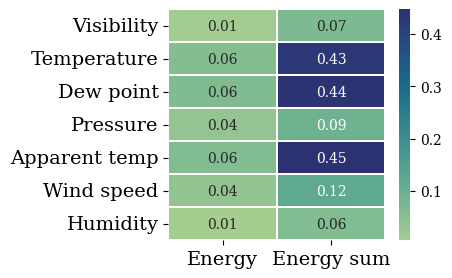

In [ ]:
plt.figure(figsize=[3.5,3])
sb.heatmap(df44,annot =True,fmt ='.2f',cmap='crest',linewidth=0.05)
plt.xticks(fontsize = 14  )
plt.yticks(fontsize = 14)
#ax = figure.add_subplot(111)

from google.colab import files
plt.savefig("Heatmap for absolute correlation of energy and energy sum with weather variables.png",dpi = 300,bbox_inches= 'tight')
files.download("Heatmap for absolute correlation of energy and energy sum with weather variables.png")